In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
from tqdm import tqdm
sns.set_theme(style="darkgrid", palette="Set2")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "text.usetex": True
})

os.environ["PATH"] = os.path.expanduser("~/texlive2025/bin/x86_64-linux") + os.pathsep + os.environ.get("PATH", "")



In [38]:
def combine_results_all(max_num_jobs, types, db_path="results.sqlite"):
    if os.path.exists(db_path):
        os.remove(db_path)
    for type in tqdm(types):
        for with_clone in ["_with_clone", "_without_clone"]:
            for postfix in ["", "_yrwr"]:
                combine_results(max_num_jobs, f"{type}{postfix}{with_clone}", db_path, if_exists="append")

        combine_results(max_num_jobs, f"{type}_kt_distance_with_clone", db_path, if_exists="append")
        combine_results(max_num_jobs, f"{type}_kt_distance_yrwr_with_clone", db_path, if_exists="append")



def combine_results(max_num_jobs, table, db_path="results.sqlite", if_exists="replace"):
    with sqlite3.connect(db_path) as out_conn:
        # We'll keep a running list of dfs per type
        all_= []

        for i in range(max_num_jobs):
            in_path = f"results/job_{i}.sqlite"
            if not os.path.exists(in_path):
                continue
            with sqlite3.connect(in_path) as in_conn:
                try:
                    df = pd.read_sql(f"SELECT * FROM {table}", in_conn)
                    all_.append(df)
                except pd.errors.DatabaseError:
                    print(f"Error reading {table} for job {i}")

        if all_:
            concat = pd.concat(all_, ignore_index=True)
            concat.to_sql(table, out_conn, if_exists=if_exists, index=False)

def plot_modalities(df, ax, title):
    sns.lineplot(data=df, ax=ax, palette="plasma", dashes=False, marker="o")
    ax.set_title(title)
    ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_xticks(range(1, 6))

def plot_rank_differences(df_with_clone, df_without_clone, ax, title):
    diff = df_without_clone.mean() - df_with_clone.groupby("num_clones").mean()
    plot_modalities(diff, ax, title)

def plot_ranks(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    model_names = list(df.index)
    sns.boxplot(data=df, ax=ax)
    ax.set_xlabel("Model")
    ax.set_ylabel("Rank")
    ax.set_xticklabels(model_names, rotation=90)
    plt.show()

def load_all(table, db_path="results.sqlite"):
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql(f"SELECT * FROM {table}", conn)

In [39]:
# TYPES = ["coding", "ahp", "image-edit", "text", "text-to-image", "text-to-video", "vision", "webdev"]
top_level_types = ["text", "vision","text_coding", "webdev", "texttoimage", "imageedit", "imagetovideo"]
occuptationals = ["text_occupational_" + t for t in ["business", "entertainment", "legal", "life_physical_social_science", "mathematical", "software_it_services", "writing_literature", "medicine"]]
text_categories = ["text_" + t for t in ["expert", "hard_prompts", "instruction_following", "longer_query", "multiturn"]]
# vision_categories = ["vision_" + t for t in ["captioning", "diagram", "ocr"]]
TYPES = top_level_types + text_categories
TYPES_WITHOUT_DASHES = [t.replace("-", "") for t in TYPES]

combine_results_all(50, TYPES_WITHOUT_DASHES)

with sqlite3.connect("results.sqlite") as conn:
    cursor = conn.cursor()
    tables = cursor.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
    print("Tables in the database:", [t[0] for t in tables])


100%|██████████| 12/12 [03:32<00:00, 17.74s/it]

Tables in the database: ['text_with_clone', 'text_yrwr_with_clone', 'text_without_clone', 'text_yrwr_without_clone', 'text_kt_distance_with_clone', 'text_kt_distance_yrwr_with_clone', 'vision_with_clone', 'vision_yrwr_with_clone', 'vision_without_clone', 'vision_yrwr_without_clone', 'vision_kt_distance_with_clone', 'vision_kt_distance_yrwr_with_clone', 'text_coding_with_clone', 'text_coding_yrwr_with_clone', 'text_coding_without_clone', 'text_coding_yrwr_without_clone', 'text_coding_kt_distance_with_clone', 'text_coding_kt_distance_yrwr_with_clone', 'webdev_with_clone', 'webdev_yrwr_with_clone', 'webdev_without_clone', 'webdev_yrwr_without_clone', 'webdev_kt_distance_with_clone', 'webdev_kt_distance_yrwr_with_clone', 'texttoimage_with_clone', 'texttoimage_yrwr_with_clone', 'texttoimage_without_clone', 'texttoimage_yrwr_without_clone', 'texttoimage_kt_distance_with_clone', 'texttoimage_kt_distance_yrwr_with_clone', 'imageedit_with_clone', 'imageedit_yrwr_with_clone', 'imageedit_without_

In [40]:
TYPE_NAMES = {
    "text": "Text",
    "vision": "Vision",
    "text_coding": "Coding",
    "webdev": "Web Development",
    "texttoimage": "Text to Image",
    "imageedit": "Image Edit",
    "search": "Search",
    "imagetovideo": "Image to Video",
    "text_creative_writing": "Creative Writing",
    "text_expert": "Expert",
    "text_hard_prompts": "Hard Prompts",
    "text_instruction_following": "Instruction Following",
    "text_longer_query": "Longer Query",
    "text_multiturn": "Multiturn",
    "text_occupational_business": "Occupational: Business",
    "text_occupational_entertainment": "Occupational: Entertainment",
    "text_occupational_legal": "Occupational: Legal",
    "text_occupational_life_physical_social_science": "Occupational: Life, Physical, Social Science",
    "text_occupational_mathematical": "Occupational: Mathematical",
    "text_occupational_software_it_services": "Occupational: Software, IT Services",
    "text_occupational_writing_literature": "Occupational: Writing, Literature",
    "text_occupational_medicine": "Occupational: Medicine",
    "vision_captioning": "Captioning",
    "vision_diagram": "Diagram",
    "vision_ocr": "OCR",
}

In [41]:
df_with_clone = {}
df_without_clone = {}
df_yrwr_with_clone = {}
df_yrwr_without_clone = {}
df_kt_distance_with_clone = {}
df_kt_distance_yrwr_with_clone = {}

for type in TYPES_WITHOUT_DASHES:
    TABLE_WITH_CLONE = f"{type}_with_clone"
    TABLE_WITHOUT_CLONE = f"{type}_without_clone"
    TABLE_YRWR_WITH_CLONE = f"{type}_yrwr_with_clone"
    TABLE_YRWR_WITHOUT_CLONE = f"{type}_yrwr_without_clone"
    TABLE_KT_DISTANCE_WITH_CLONE = f"{type}_kt_distance_with_clone"
    TABLE_KT_DISTANCE_YRWR_WITH_CLONE = f"{type}_kt_distance_yrwr_with_clone"
    df_with_clone[type] = load_all(TABLE_WITH_CLONE)
    df_without_clone[type] = load_all(TABLE_WITHOUT_CLONE)
    df_yrwr_with_clone[type] = load_all(TABLE_YRWR_WITH_CLONE)
    df_yrwr_without_clone[type] = load_all(TABLE_YRWR_WITHOUT_CLONE)
    df_kt_distance_with_clone[type] = load_all(TABLE_KT_DISTANCE_WITH_CLONE)
    df_kt_distance_yrwr_with_clone[type] = load_all(TABLE_KT_DISTANCE_YRWR_WITH_CLONE)


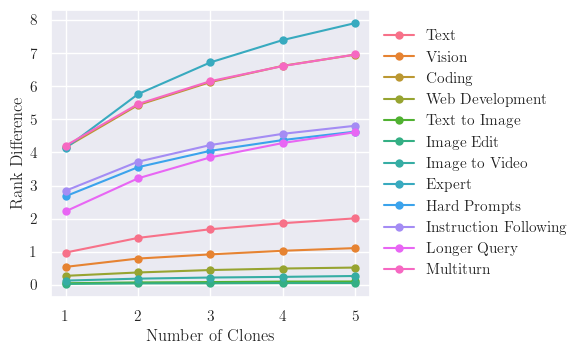

In [42]:
fig, ax = plt.subplots(figsize=(6, 3.7))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
# means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means[type] = (df_without_clone[type].mean() - df_with_clone[type].groupby("num_clones").mean()).mean(axis=1)
    # means_yrwr[type] = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean()).mean(axis=1)

sns.lineplot(data=means, dashes=False, marker="o", markeredgewidth=0, ax=ax)

# ax.set_ylim(-0.1, 10)
ax.set_xlabel("Number of Clones")
ax.set_ylabel("Rank Difference")
ax.set_xticks(range(1, 6))

ax.get_legend().remove()

handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
# plt.savefig("plots/rank_difference.png", dpi=500)

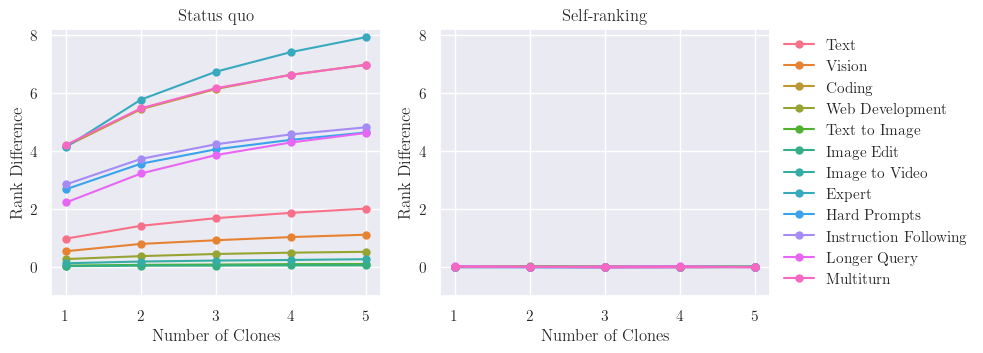

In [43]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.7))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means[type] = (df_without_clone[type].mean() - df_with_clone[type].groupby("num_clones").mean()).mean(axis=1)
    means_yrwr[type] = (df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type].groupby("num_clones").mean()).mean(axis=1)

sns.lineplot(data=means, dashes=False, marker="o", markeredgewidth=0, ax=axes[0])
sns.lineplot(data=means_yrwr, dashes=False, marker="o", markeredgewidth=0, ax=axes[1])

axes[0].set_ylim(-1, 8.2)
axes[1].set_ylim(-1, 8.2)

for ax in axes:
    ax.set_xlabel("Number of Clones")
    ax.set_ylabel("Rank Difference")
    ax.set_xticks(range(1, 6))
    ax.get_legend().remove()

axes[0].set_title("Status quo")
axes[1].set_title("Self-ranking")

handles, old_labels = axes[0].get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
axes[1].legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
# plt.savefig("plots/rank_difference_contrast.png", dpi=500)

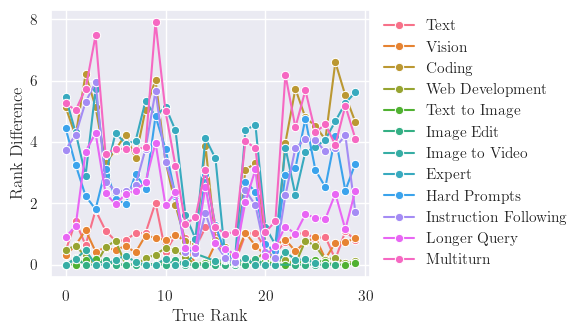

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3.5))

max_rank = 30

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
means_yrwr = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    means[type] = pd.Series((df_without_clone[type].mean() - df_with_clone[type][df_with_clone[type]["num_clones"] == 1].mean()).values[:max_rank])
    means_yrwr[type] = pd.Series((df_yrwr_without_clone[type].mean() - df_yrwr_with_clone[type][df_yrwr_with_clone[type]["num_clones"] == 1].mean()).values[:max_rank])

means["x"] = means.index
means["x_bin"] = pd.cut(means["x"], bins=30)

mean_df = (
    means.groupby("x_bin", observed=True).mean()
      .reset_index(drop=True)
)

mean_df = mean_df.set_index("x")


sns.lineplot(data=mean_df, dashes=False, marker="o", ax=ax)
# sns.lineplot(data=means_yrwr, dashes=False, marker="o", ax=axes[1])

# ax.set_ylim(-0.1, 10)
ax.set_xlabel("True Rank")
ax.set_ylabel("Rank Difference")
# ax.set_xticks(range(1, 6))

# ax.set_title("Status quo")
ax.get_legend().remove()

handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in mean_df.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()

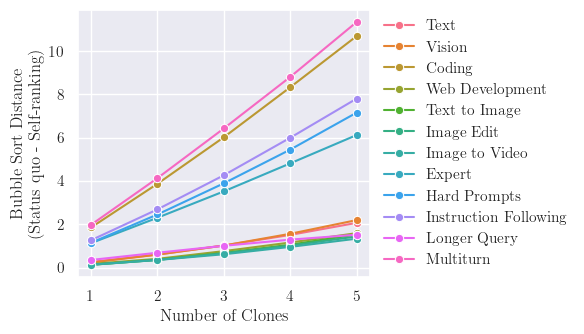

In [51]:
fig, ax = plt.subplots(figsize=(6, 3.5))

def kt_corr_to_kt_distance(kt_corr, M):
    return (1 - kt_corr) * M * (M-1) / 4

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    M = len(df_kt_distance_yrwr_with_clone[type].columns)
    means[type] = (kt_corr_to_kt_distance(df_kt_distance_with_clone[type].groupby("num_clones").mean(), M) - kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1)


sns.lineplot(data=means, dashes=False, marker="o", ax=ax)
# ax.set_yscale("log", base=2)

ax.set_xlabel("Number of Clones")
ax.set_ylabel("Bubble Sort Distance\n(Status quo - Self-ranking)")
ax.set_xticks(range(1, 6))
handles, old_labels = ax.get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]
ax.legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
plt.tight_layout()
plt.savefig("plots/bubble_sort_distance.png", dpi=500)

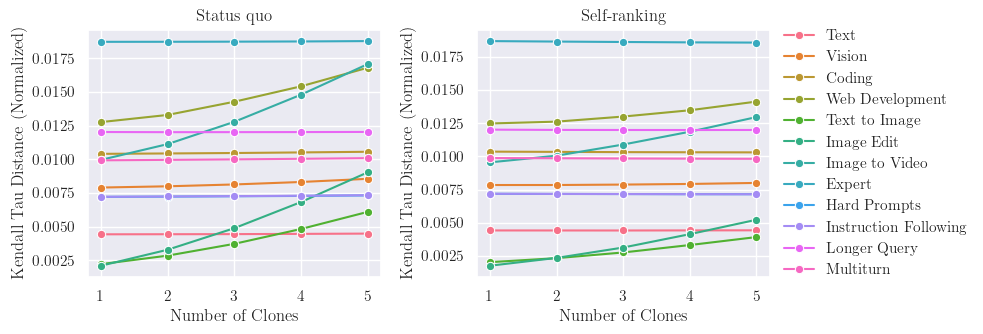

In [58]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3.5))

means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
yrwr_means = pd.DataFrame(columns=TYPES_WITHOUT_DASHES)
for type in TYPES_WITHOUT_DASHES:
    M = len(df_kt_distance_yrwr_with_clone[type].columns)
    # means[type] = (df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean() - df_kt_distance_with_clone[type].groupby("num_clones").mean()).mean(axis=1) * M * (M-1) / 2
    means[type] = (kt_corr_to_kt_distance(df_kt_distance_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1) / (M * (M-1) / 2)
    yrwr_means[type] = (kt_corr_to_kt_distance(df_kt_distance_yrwr_with_clone[type].groupby("num_clones").mean(), M)).mean(axis=1) / (M * (M-1) / 2)


sns.lineplot(data=means, dashes=False, marker="o", ax=axes[0])
sns.lineplot(data=yrwr_means, dashes=False, marker="o", ax=axes[1])
# ax.set_yscale("log", base=2)

for ax in axes:
    ax.set_xlabel("Number of Clones")
    ax.set_ylabel("Kendall Tau Distance (Normalized)")
    ax.set_xticks(range(1, 6))
    ax.get_legend().remove()

handles, old_labels = axes[0].get_legend_handles_labels()
new_labels = [TYPE_NAMES[t] for t in means.columns]

axes[1].legend(
    handles, 
    new_labels, 
    loc="center left", 
    bbox_to_anchor=(1, 0.5),
    frameon=False,              
    facecolor="none",        
)
axes[0].set_title("Status quo")
axes[1].set_title("Self-ranking")
plt.tight_layout()
plt.savefig("plots/bubble_sort_distance_double.png", dpi=500)


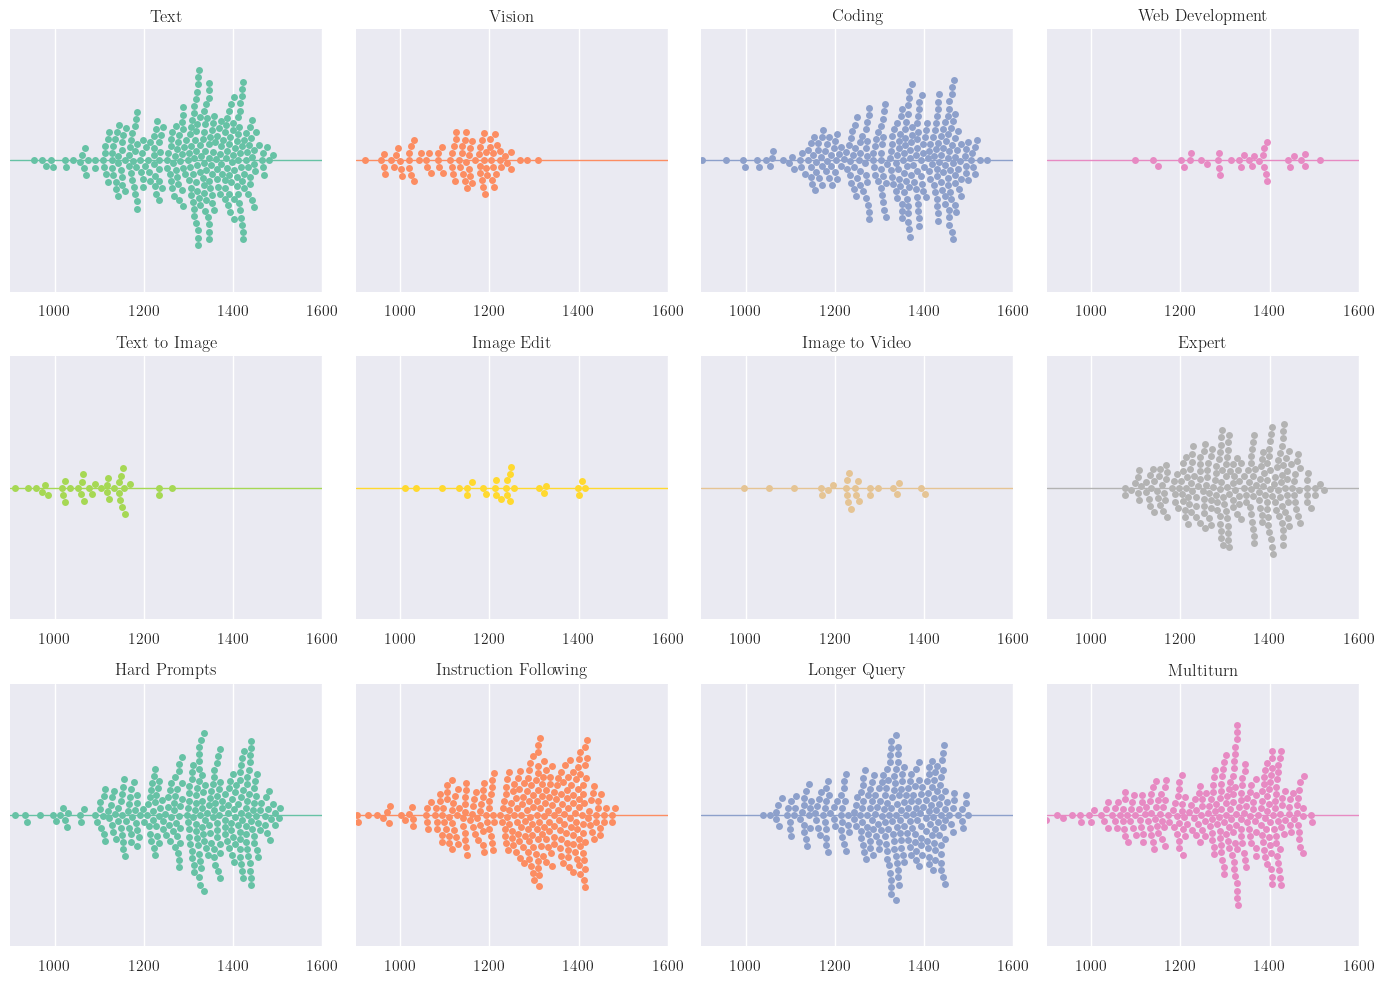

In [23]:
scores_dfs = {}
for type in TYPES_WITHOUT_DASHES:
    df = pd.read_csv(f"parsed_tables/{type}.csv")
    scores_dfs[type] = df

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(14, 10))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    sns.swarmplot(
        data=scores_dfs[type],
        x="Score",
        alpha=1,
        size=5,
        ax=axes[i//4, i%4],
        color=f"C{i}"
    )
    axes[i//4, i%4].axhline(y=0, lw=1, color=f"C{i}")
    axes[i//4, i%4].set_title(TYPE_NAMES[type])
    axes[i//4, i%4].set(yticks=[], ylabel="")
    axes[i//4, i%4].set_xlim(900, 1600)
    axes[i//4, i%4].set_yticks([])
    axes[i//4, i%4].set_xlabel("")
    axes[i//4, i%4].set_ylabel("")
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

# Make unused axes (if any) invisible
for ax_row in axes:
    for ax in (ax_row if isinstance(ax_row, (list, np.ndarray)) else [ax_row]):
        if not ax.has_data():
            ax.set_visible(False)

plt.tight_layout()
plt.show()

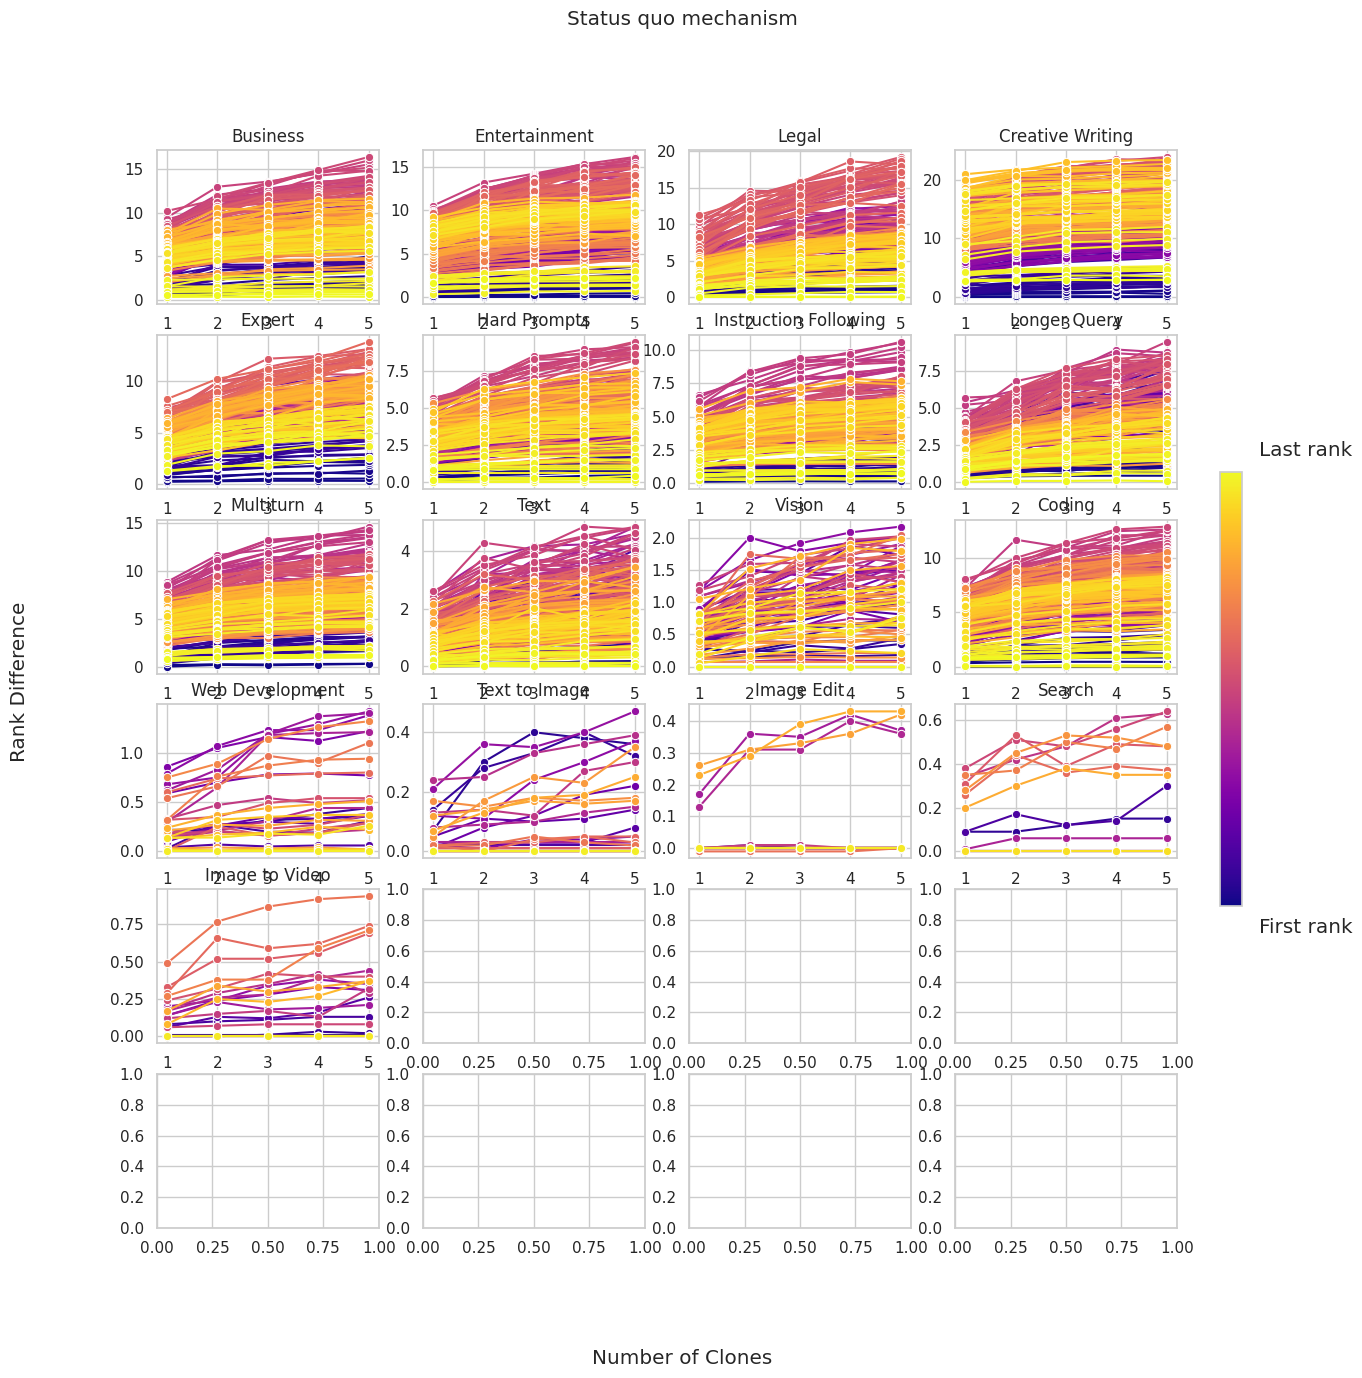

In [15]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(14, 14))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_with_clone[type], df_without_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Rank Difference")
fig.suptitle("Status quo mechanism")
# axes[0, 3].legend(loc="center left", bbox_to_anchor=(1, 0.5))
import matplotlib as mpl

cmap = plt.cm.plasma
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm, ax=axes, location='right', fraction=0.02, pad=0.04)
cbar.ax.text(1.8, 1.05, "Last rank", ha='left', va='center', fontsize="large", transform=cbar.ax.transAxes)
cbar.ax.text(1.8, -0.05, "First rank", ha='left', va='center', fontsize="large", transform=cbar.ax.transAxes)
cbar.set_ticks([])
cbar.set_label("")  

plt.show()


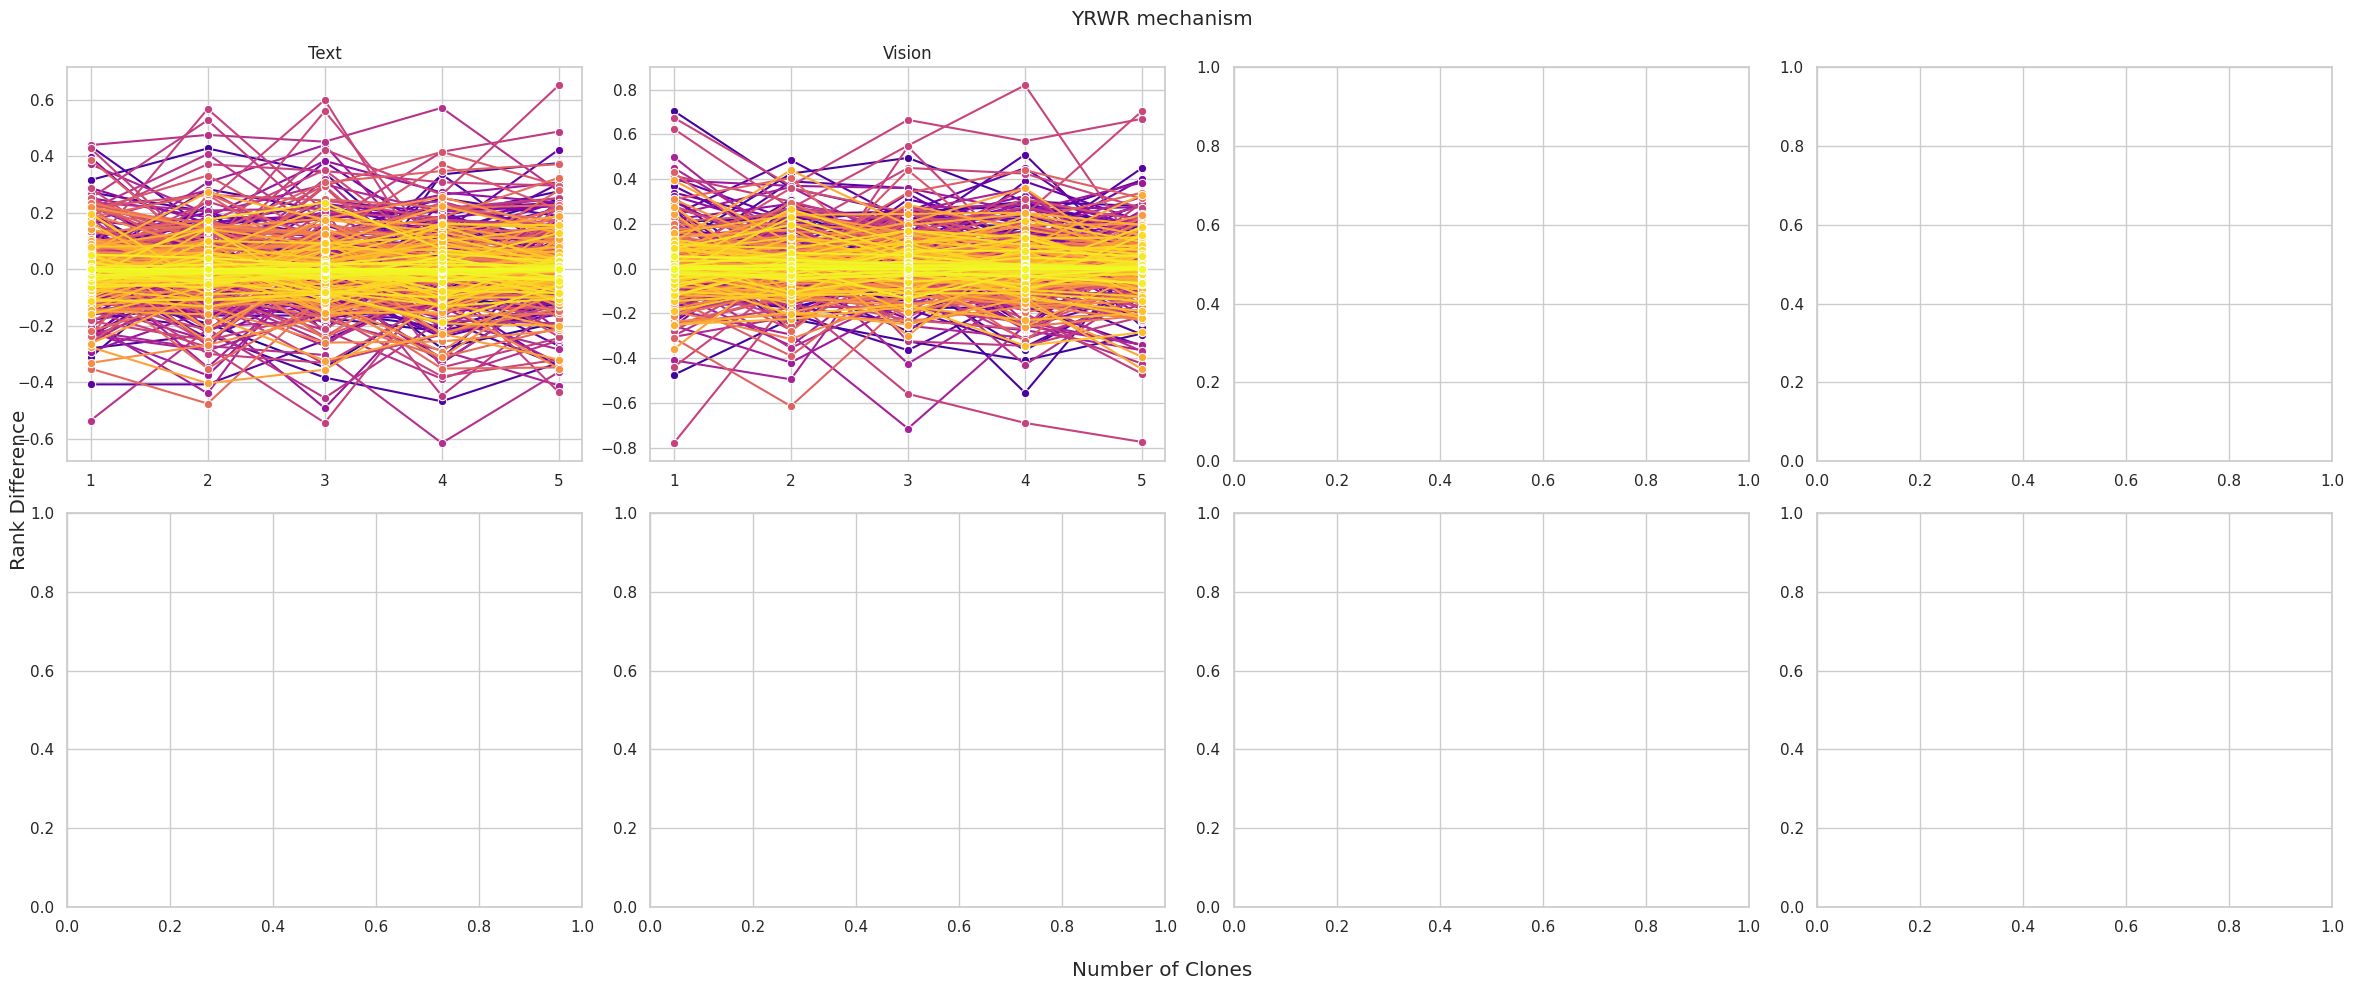

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_yrwr_with_clone[type], df_yrwr_without_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Rank Difference")
fig.suptitle("YRWR mechanism")
# axes[0, 0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

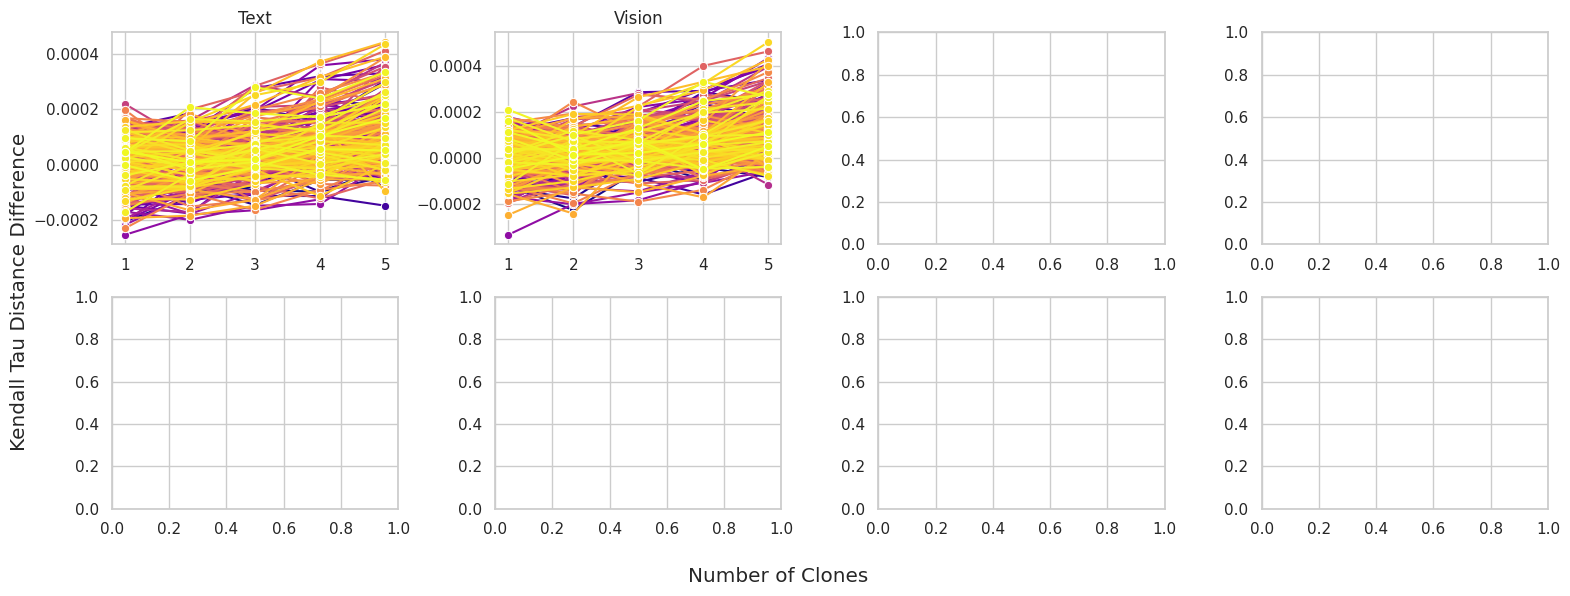

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
for i, type in enumerate(TYPES_WITHOUT_DASHES):
    plot_rank_differences(df_kt_distance_with_clone[type], df_kt_distance_yrwr_with_clone[type], axes[i//4, i%4], TYPE_NAMES[type])

fig.supxlabel("Number of Clones")
fig.supylabel("Kendall Tau Distance Difference")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1231814/1854762200.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=90)


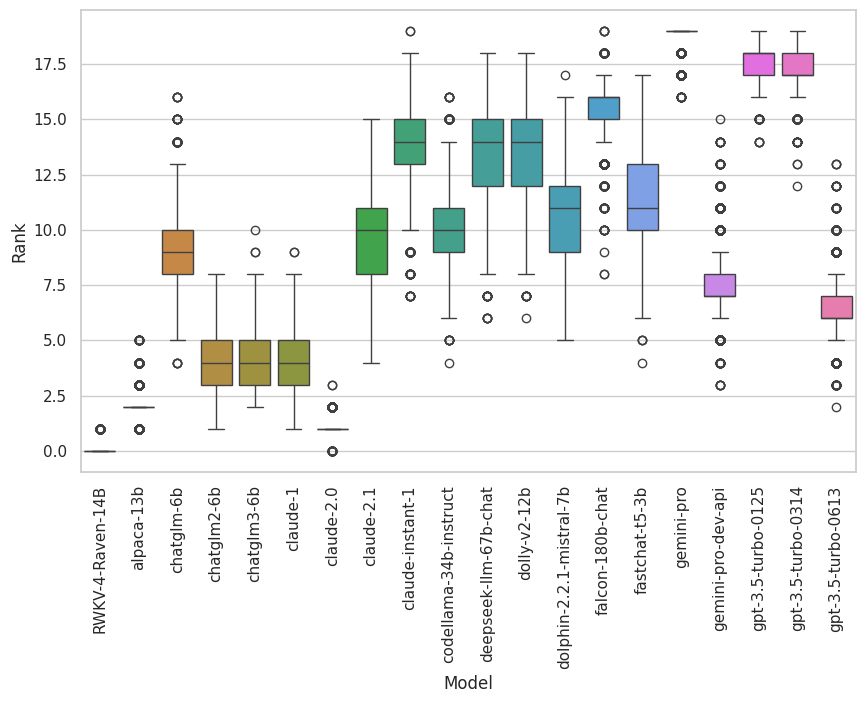

In [125]:
plot_ranks(df_without_clone)

# Arena Human Preference preprocessing

In [37]:
from rank_quality import fit_bt_model

In [44]:
df = pd.read_csv("hf://datasets/lmarena-ai/arena-human-preference-55k/train.csv")
df = df[df["winner_tie"] == 0]
df.loc[df["winner_model_a"] == 1, "winner"] = df["model_a"]
df.loc[df["winner_model_a"] == 0, "loser"] = df["model_a"]
df.loc[df["winner_model_b"] == 1, "winner"] = df["model_b"]
df.loc[df["winner_model_b"] == 0, "loser"] = df["model_b"]

In [49]:
all_models = pd.Index(df['winner'].unique()).union(df['loser'].unique())
win_counts = pd.DataFrame(np.zeros((len(all_models), len(all_models))), index=all_models, columns=all_models)
battle_counts = pd.DataFrame(np.zeros((len(all_models), len(all_models))), index=all_models, columns=all_models)

for _, row in df.iterrows():
    win_counts.loc[row['winner'], row['loser']] += 1
    battle_counts.loc[row['winner'], row['loser']] += 1
    battle_counts.loc[row['loser'], row['winner']] += 1

for i in range(len(all_models)):
    for j in range(i):
        if battle_counts.iloc[i, j] > 0:
            win_counts.iloc[i, j] = win_counts.iloc[i, j] / battle_counts.iloc[i, j]
            win_counts.iloc[j, i] = 1 - win_counts.iloc[i, j]
        else:
            win_counts.iloc[i, j] = np.nan
            win_counts.iloc[j, i] = np.nan
    win_counts.iloc[i, i] = np.nan
    battle_counts.iloc[i, i] = 0

bt_scores, _ = fit_bt_model(win_counts, battle_counts)
sorted_indices = np.argsort(bt_scores)[::-1]
win_counts = win_counts.iloc[sorted_indices, sorted_indices]
battle_counts = battle_counts.iloc[sorted_indices, sorted_indices]


win_counts.to_csv("parsed_heatmaps/ahp_win_rates.csv")
battle_counts.to_csv("parsed_heatmaps/ahp_battle_counts.csv")


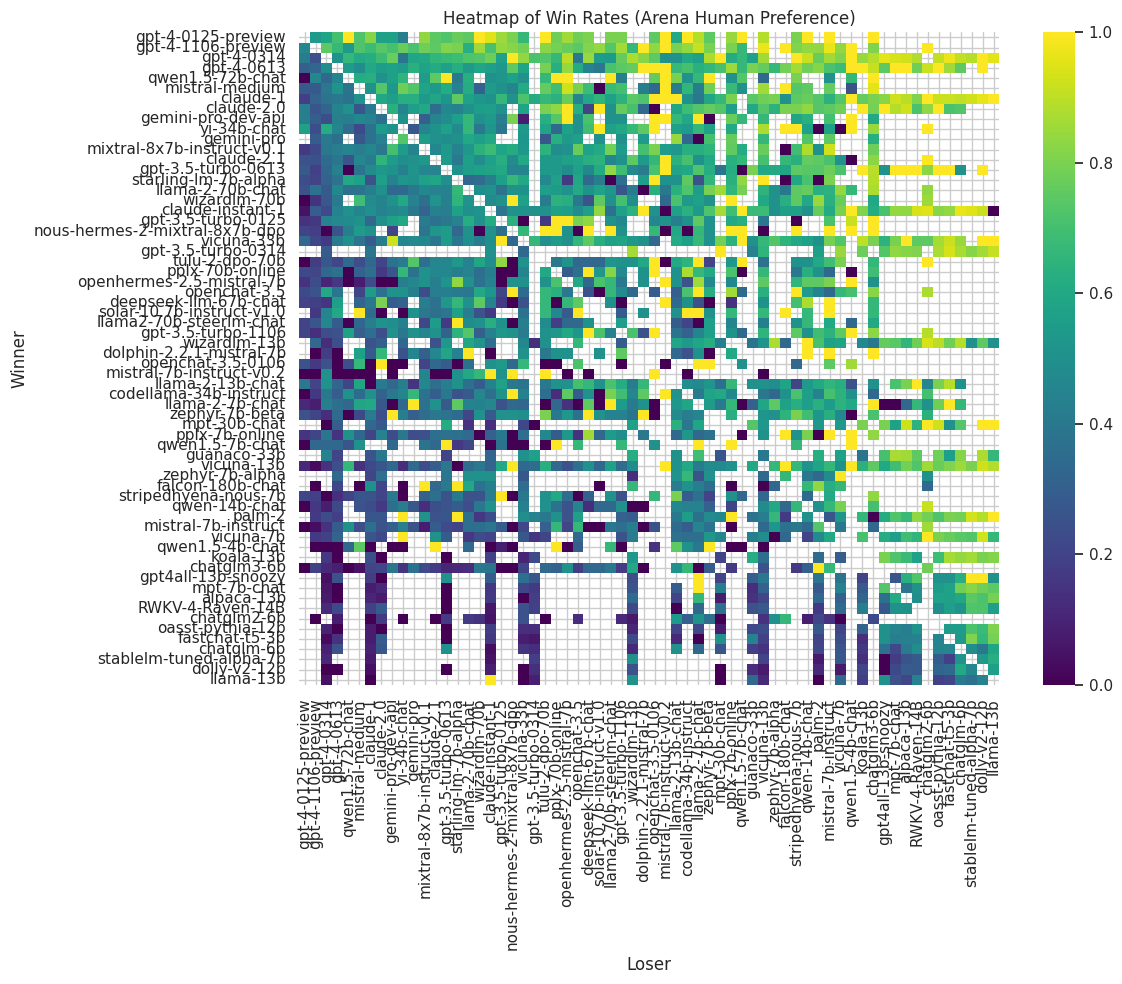

In [50]:
plt.figure(figsize=(12, 10))
sns.heatmap(win_counts, cmap="viridis", annot=False, xticklabels=True, yticklabels=True)
plt.title("Heatmap of Win Rates (Arena Human Preference)")
plt.xlabel("Loser")
plt.ylabel("Winner")
plt.tight_layout()
plt.show()
